# Compare Inversion Calls Across Treatments
What would be interesting to see is the inversion-calling performance in linked reads across inversion sizes and depths. Since we already created the assessment tables from the individual size-class data exploration, we can read those in without having to reprocess those data.

In [67]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(ggh4x)
library(ggpubr)
options(warn = -1)

Read in the LEVIATHAN linked-read variant assessments. Remove the `inversion` and `id` columns. We will add the leviathan candidates as their own `technology` and do the same with the pooled data.

In [68]:
.lev <- read.csv("assess_sv_leviathan/visor/linkedread.sv.assessment", header = T) %>%
    select(-inversion, -id, -candidate)
.lev$technology[.lev$sample == 11] <- "linkedread (pooled)"
.lev$zygosity[.lev$sample == 11] <- "homozygous"

# rm pooled from the candidates
.lev_cand <- select(.lev, -assessment) %>% rename("assessment" = assess_cand) %>% filter(sample < 11)

# rename the false negative (filtered) to "true positive" to posit an ideal world where candidates were detected
.lev_cand$assessment[grepl("filtered", .lev_cand$assessment)] <- "true positive"
.lev_cand$assessment[grepl("undetected", .lev_cand$assessment)] <- "false negative"
.lev_cand$technology <- "linkedread (candidates)"

leviathan <- rbind(select(.lev, -assess_cand), .lev_cand)

table(leviathan$technology)
table(leviathan$assessment)
head(leviathan)


             linkedread linkedread (candidates)     linkedread (pooled) 
                   2400                    2400                     240 


false negative  true negative  true positive 
          1236           1300           2504 

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan


In [69]:
naibr <- read.csv("assess_sv_naibr/visor/linkedread.sv.assessment", header = T) %>%
    select(-inversion, -id)
table(naibr$assessment)
head(naibr)


false negative  true negative  true positive 
          1323            650            667 

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr


For the short reads, we can rename the values in the `technology` column as `shortread`

In [70]:
delly <- read.csv("assess_sv_delly/linkedread.sv.assessment", header = T)
delly$technology <- "shortread"
delly <- select(delly, -inversion, -id)
table(delly$assessment)
head(delly)


false negative  true negative  true positive 
           407            650           1343 

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,shortread,delly2


Read in the long-read variant assessment. Rename the columns because I clearly wasn't consistent doing this over and over again.

In [71]:
longread <- read.csv("longread_workflow/longread.sv.assessment", header = T)
longread <- rename(longread, "simulated" = present, "technology" = platform)
longread$method <- "sniffles"
longread$sample <- as.integer(gsub("sample_", "", longread$sample))
table(longread$assessment)
head(longread)


false negative  true negative  true positive 
          1194           1950           4056 

,sample,contig,position_start,position_end,size,simulated,zygosity,assessment,depth,technology,method
,<int>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,1,2L,11529165,15060030,large,TRUE,homozygous,false negative,0.5,pacbio,sniffles
2,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,0.5,ontlong,sniffles
3,1,2L,11529165,15060030,large,TRUE,homozygous,false negative,0.5,ontshort,sniffles
4,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,2.0,pacbio,sniffles
5,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,2.0,ontlong,sniffles
6,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,2.0,ontshort,sniffles


In [72]:
assess <- rbind(leviathan, naibr, delly, longread)
head(assess)

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan


Let's also make some of the columns factors.

In [73]:
#assess$depth <- as.factor(assess$depth)
assess$size <- factor(assess$size, ordered = T, levels = c("small","medium","large","xl"))
assess$technology <- factor(assess$technology, ordered = T, levels = c("linkedread", "linkedread (pooled)", "linkedread (candidates)", "shortread", "ontshort", "ontlong", "pacbio"))
assess$zygosity <- as.factor(assess$zygosity)
assess$assessment <- as.factor(assess$assessment)
assess$method <- as.factor(assess$method)

head(assess, 10)

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<ord>,<lgl>,<fct>,<int>,<int>,<fct>,<ord>,<fct>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
7,2L,2.0,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
8,2L,5.0,2,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
9,2L,10.0,2,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan


## Sample-level Calling
### Prepare the Data
It would probably make sense to collapse these data somewhat to show a representation of true positives vs false negatives (as a ratio) across depths (x axis) and faceted for hom/het. We will also remove inversions that weren't simulated for a sample b/c we aren't interested in true negatives (since there were no false positives). Let's also remove `naibr` (for now).

In [74]:
.assess <- as.vector(outer(c("true", "false"), c("positive", "negative"), paste))
samples <- assess[assess$method != "naibr",] %>%
    group_by(size, depth, zygosity, assessment, technology) %>%
    summarize(count = n()) %>% ungroup() %>%
    complete(size, depth, zygosity, technology, assessment = .assess[c(-2)], fill = list(count = 0))

head(samples)

`summarise()` has grouped output by 'size', 'depth', 'zygosity', 'assessment'.
You can override using the `.groups` argument.


size,depth,zygosity,technology,assessment,count
<ord>,<dbl>,<fct>,<ord>,<chr>,<int>
small,0.5,heterozygous,linkedread,false negative,72
small,0.5,heterozygous,linkedread,true negative,0
small,0.5,heterozygous,linkedread,true positive,2
small,0.5,heterozygous,linkedread (pooled),false negative,0
small,0.5,heterozygous,linkedread (pooled),true negative,0
small,0.5,heterozygous,linkedread (pooled),true positive,0


In [75]:
# this function automates reading in everything all at once returns an empty table if there are no false positives
read.fp <- function(dir){
    val <- Reduce(
       rbind,
        Map(
            function(x){ read.table(x, header = T)},
            list.files(dir, pattern = "false_positives*", full.names = T)
        )
    )
    if (is.null(val)){
        return(
            data.frame(
                contig = character(),
                position_start = integer(),
                position_end = integer(),
                sample = integer(),
                depth = numeric(),
                size = character(),
                method = character()
            )
        )
    } else {
        return(val)
    }
}

In [76]:
false_positives <- Reduce(
    rbind,
    Map(
        read.fp,
        c("assess_sv_delly", "assess_sv_leviathan/visor", "longread_workflow")
    )
)

false_positives$assessment <- "false positive"
false_positives <- rename(false_positives, "technology" = method)
false_positives$technology <- gsub("delly", "shortread", false_positives$technology)
false_positives$zygosity <- case_when(
    false_positives$contig == "2L" ~ "homozygous",
    false_positives$contig == "2R" ~ "heterozygous",
    false_positives$contig == "3R" ~ "homozygous",
    false_positives$contig == "3L" ~ "heterozygous"
)
head(false_positives)

samples_consolidated <- group_by(samples, size, depth, technology, assessment, zygosity) %>%
    summarise(count = sum(count)) %>% ungroup()
head(samples_consolidated)


samples_consolidated_noz <- group_by(samples, size, depth, technology, assessment) %>%
    summarise(count = sum(count)) %>% ungroup()
head(samples_consolidated_noz)

,contig,position_start,position_end,sample,depth,size,technology,assessment,zygosity
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,2L,6436108,6636405,4,0.5,medium,shortread,false positive,homozygous
2,3L,1700609,1761574,9,0.5,medium,shortread,false positive,heterozygous
3,3L,1700628,1761915,1,0.5,medium,shortread,false positive,heterozygous
4,3L,1700628,1761915,6,0.5,medium,shortread,false positive,heterozygous
5,2L,6436142,6636405,1,2.0,medium,shortread,false positive,homozygous
6,2L,6436142,6636405,2,2.0,medium,shortread,false positive,homozygous


`summarise()` has grouped output by 'size', 'depth', 'technology',
'assessment'. You can override using the `.groups` argument.


size,depth,technology,assessment,zygosity,count
<ord>,<dbl>,<ord>,<chr>,<fct>,<int>
small,0.5,linkedread,false negative,heterozygous,72
small,0.5,linkedread,false negative,homozygous,67
small,0.5,linkedread,true negative,heterozygous,0
small,0.5,linkedread,true negative,homozygous,57
small,0.5,linkedread,true positive,heterozygous,2
small,0.5,linkedread,true positive,homozygous,2


`summarise()` has grouped output by 'size', 'depth', 'technology'. You can
override using the `.groups` argument.


size,depth,technology,assessment,count
<ord>,<dbl>,<ord>,<chr>,<int>
small,0.5,linkedread,false negative,139
small,0.5,linkedread,true negative,57
small,0.5,linkedread,true positive,4
small,0.5,linkedread (pooled),false negative,10
small,0.5,linkedread (pooled),true negative,0
small,0.5,linkedread (pooled),true positive,10


In [77]:
metrics <- group_by(false_positives, size, depth, assessment, technology, zygosity) %>%
    summarize(count = n()) %>% ungroup() %>%
    rbind(samples_consolidated) %>%
    arrange(size, depth, technology, assessment) %>%
    filter(technology != "linkedread (candidates)") %>%
    complete(size, depth, technology, zygosity, assessment = .assess, fill = list(count = 0)) %>%
    pivot_wider(names_from = assessment, values_from = count) %>%
    rename(FN = "false negative", FP = "false positive", TN = "true negative", TP = "true positive")
#names(metrics) <- c("size", "depth", "technology", "zygosity", "FN", "FP", "TN", "TP")
head(metrics)

`summarise()` has grouped output by 'size', 'depth', 'assessment',
'technology'. You can override using the `.groups` argument.


size,depth,technology,zygosity,FN,FP,TN,TP
<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<int>
large,0.5,linkedread,heterozygous,30,0,0,0
large,0.5,linkedread,homozygous,28,0,21,1
large,0.5,linkedread (pooled),heterozygous,0,0,0,0
large,0.5,linkedread (pooled),homozygous,2,0,0,6
large,0.5,ontlong,heterozygous,27,0,0,3
large,0.5,ontlong,homozygous,25,0,21,4


In [78]:
metrics$precision <- metrics$TP / (metrics$TP + metrics$FP)
metrics$recall <- metrics$TP / (metrics$TP + metrics$FN)
metrics$F1 <- 2 * ((metrics$precision * metrics$recall) / (metrics$precision + metrics$recall))
metrics$depth <- metrics$depth
metrics$size <- factor(metrics$size, ordered = T, levels = c("small", "medium", "large", "xl"))
metrics$depth <- as.numeric(metrics$depth)
metrics$Accuracy <- (metrics$TP + metrics$TN) / (metrics$TP + metrics$TN + metrics$FN + metrics$FP)
metrics$FPR <- metrics$FP / (metrics$FP + metrics$TN)
metrics[is.na(metrics)] <- 0

head(metrics)

metrics_global <- group_by(metrics, technology, depth, zygosity) |>
    summarize(FN = sum(FN), FP = sum(FP), TN = sum(TN), TP = sum(TP))
metrics_global$precision <- metrics_global$TP / (metrics_global$TP + metrics_global$FP)
metrics_global$recall <- metrics_global$TP / (metrics_global$TP + metrics_global$FN)
metrics_global$F1 <- 2 * ((metrics_global$precision * metrics_global$recall) / (metrics_global$precision + metrics_global$recall))
metrics_global$depth <- metrics_global$depth
metrics_global$depth <- as.numeric(metrics_global$depth)
metrics_global$Accuracy <- (metrics_global$TP + metrics_global$TN) / (metrics_global$TP + metrics_global$TN + metrics_global$FN + metrics_global$FP)
metrics_global$FPR <- metrics_global$FP / (metrics_global$FP + metrics_global$TN)
metrics_global[is.na(metrics_global)] <- 0

head(metrics_global)

size,depth,technology,zygosity,FN,FP,TN,TP,precision,recall,F1,Accuracy,FPR
<ord>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
large,0.5,linkedread,heterozygous,30,0,0,0,0,0.00000000,0.00000000,0.00,0
large,0.5,linkedread,homozygous,28,0,21,1,1,0.03448276,0.06666667,0.44,0
large,0.5,linkedread (pooled),heterozygous,0,0,0,0,0,0.00000000,0.00000000,0.00,0
large,0.5,linkedread (pooled),homozygous,2,0,0,6,1,0.75000000,0.85714286,0.75,0
large,0.5,ontlong,heterozygous,27,0,0,3,1,0.10000000,0.18181818,0.10,0
large,0.5,ontlong,homozygous,25,0,21,4,1,0.13793103,0.24242424,0.50,0


`summarise()` has grouped output by 'technology', 'depth'. You can override
using the `.groups` argument.


technology,depth,zygosity,FN,FP,TN,TP,precision,recall,F1,Accuracy,FPR
<chr>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
linkedread,0.5,heterozygous,179,0,0,2,1,0.01104972,0.02185792,0.01104972,0
linkedread,0.5,homozygous,163,0,130,6,1,0.03550296,0.06857143,0.45484950,0
linkedread,2.0,heterozygous,152,0,0,29,1,0.16022099,0.27619048,0.16022099,0
linkedread,2.0,homozygous,103,0,130,66,1,0.39053254,0.56170213,0.65551839,0
linkedread,5.0,heterozygous,71,0,0,110,1,0.60773481,0.75601375,0.60773481,0
linkedread,5.0,homozygous,46,0,130,123,1,0.72781065,0.84246575,0.84615385,0


In [79]:
write.table(metrics, file = "metrics.csv", quote = F, sep = ",", row.names = F)
write.table(metrics_global, file = "metrics.overall.csv", quote = F, sep = ",", row.names = F)

Let's also set a color palette for the technology comparisons using the [Arches theme](https://github.com/katiejolly/nationalparkcolors/tree/master) and the Redwoods theme for the depths.

In [80]:
tech_colors <- c(
    "linkedread" = "#a8cdec",
    #"linkedread (candidates)" = "#a8cdec",
    "linkedread (pooled)" = "#6c7780",
    "ontlong" = "#682c37",
    "ontshort" = "#9b6981",
    "pacbio" = "#f6955e" ,
    "shortread" = "#7285c3ff"
)

size_colors <- c(
    "#c0c6cf",
    "#a2aab5",
    "#6e7684",
    "#54546c"
)

depth_colors <- c(
    "#c0c6cf",
    "#a2aab5",
    "#6e7684",
    "#54546c",
    "#30303dff"
)

zygosity_colors <- c(
    "#85a98eff",
    "#7fa9b4ff"
)

technology_lines <- c(
    "linkedread" = "solid",
    "linkedread (pooled)" = "dotdash",
    "linkedread (candidates)" = "dashed",
    "shortread" = "solid", 
    "ontshort" = "solid",
    "ontlong" = "solid",
    "pacbio" = "solid"
)

technology_shapes <- c(
    "linkedread" = 17,
    "linkedread (pooled)" = 12,
    "linkedread (candidates)" = 14,
    "shortread" = 25, 
    "ontshort" = 19,
    "ontlong" = 15,
    "pacbio" = 18
)

technology_shapes2 <- c(
    "linkedread" = 17,
    "linkedread (pooled)" = 12,
    "linkedread (candidates)" = 14,
    "shortread" = 19, 
    "ontshort" = 19,
    "ontlong" = 19,
    "pacbio" = 19
)

### Visualization
We are now interested in seeing how these performed. There are several dimensions to consider here:
- depth
- inversion size
- zygotic state
- sequencing technology

#### Detection between technologies across inversion classes
We'll approach this a few different ways to try to reveal meaningful information. First let's compare how each of the technologies did within a given inversion size class.

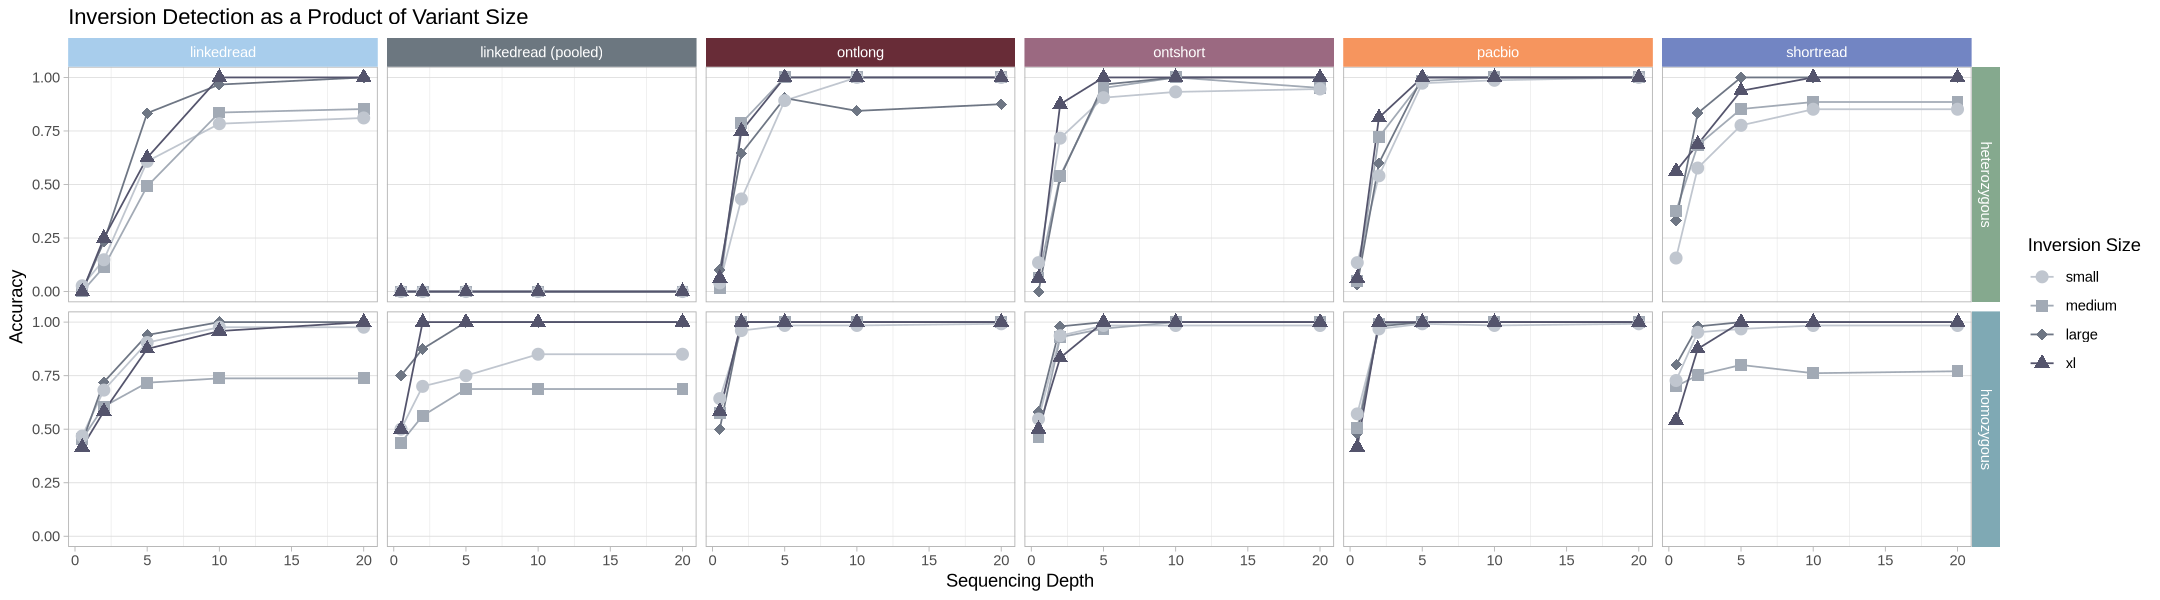

In [81]:
options(repr.plot.width = 18, repr.plot.height = 5)
.strip <- strip_themed(background_y = elem_list_rect(fill = zygosity_colors), background_x = elem_list_rect(fill = tech_colors))

filter(metrics) %>%
ggplot(aes(x = depth, y = Accuracy, color = size, group = size, shape = size)) +
    geom_line() +
    geom_point(size = 3) +
    scale_shape_manual(values = c(19,15,18,17)) +
    scale_color_manual(values = size_colors) +
    theme_light() +
    labs(title = "Inversion Detection as a Product of Variant Size", color = "Inversion Size", shape = "Inversion Size") +
    ylab("Accuracy") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(rows = vars(zygosity), cols = vars(technology), strip = .strip)

#### Holistic comparison of technologies
What does it look like when we compare the performance of hom/het within and across technologies for each inversion class?

How does this look with false positives?

Let's make it less busy by summing homozygous and heterozygous so it's a total assessment agnostic of zygotic state.

In [82]:
# Source - https://stackoverflow.com/a/18509816
# Posted by alko989, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-31, License - CC BY-SA 4.0

titlecase <- function(x) {
  substr(x, 1, 1) <- toupper(substr(x, 1, 1))
  x
}


In [83]:
plot_param <- function(param){
    paramname <- titlecase(param)
    .strip <- strip_themed(background_x = elem_list_rect(fill = zygosity_colors))
    param_zyg <- ggplot(metrics_global, aes(x = depth, y = .data[[param]], color = technology, fill = technology, shape = technology, group = technology)) +
        geom_line() +
        geom_point(size = 6) +
        theme_light() +
        scale_shape_manual(name = "Technology", values = technology_shapes) +
        scale_color_manual(name = "Technology", values = tech_colors) +
        scale_fill_manual(name = "Technology", values = tech_colors) +
        xlab("Sequencing Depth") +
        ylab(titlecase(param)) +
        labs(title = paste("Inversion Detection", paramname, "across technologies")) +
        facet_grid2(cols = vars(zygosity), strip = .strip)

    .strip <- strip_themed(background_y = elem_list_rect(fill = zygosity_colors), background_x = elem_list_rect(fill = size_colors))
    param_size <- metrics %>%
    ggplot(aes(x = depth, y = .data[[param]], color = technology, fill = technology, group = technology)) +
        geom_line(aes(linetype = technology)) +
        geom_point(size = 3, aes(shape = technology)) +
        theme_light() +
        scale_color_manual(values = tech_colors) +
        scale_fill_manual(values = tech_colors) +
        scale_linetype_manual(values = technology_lines) +
        scale_shape_manual(values = technology_shapes) +
        labs(linetype = "Technology", color = "Technology", fill = "Technology", shape = "Technology") +
        ylab(titlecase(param)) +
        xlab("Sequencing Depth") +
        theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
        facet_grid2(rows = vars(zygosity), cols = vars(size), strip = .strip)

    .strip <- strip_themed(background_y = elem_list_rect(fill = zygosity_colors), background_x = elem_list_rect(fill = depth_colors))
    param_depth <- metrics %>%
    ggplot(aes(x = size, y = .data[[param]], color = technology, fill = technology, group = technology)) +
        geom_line(aes(linetype = technology)) +
        geom_point(size = 3, aes(shape = technology)) +
        theme_light() +
        scale_color_manual(values = tech_colors) +
        scale_fill_manual(values = tech_colors) +
        scale_linetype_manual(values = technology_lines) +
        scale_shape_manual(values = technology_shapes) +
        labs(linetype = "Technology", color = "Technology", fill = "Technology", shape = "Technology") +
        ylab(titlecase(param)) +
        xlab("Variant Size") +
        theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
        facet_grid2(rows = vars(zygosity), cols = vars(depth), strip = .strip)

    param_by <- ggarrange(
        param_depth,
        param_size,
        ncol = 1, nrow = 2,
        heights = c(1, 1),
        labels = c('B', 'C'),
        label_size = 12,
        common.legend = TRUE,
        legend = "none"
    )

    paramplots <- ggarrange(
        param_zyg,
        param_by[[1]],
        ncol = 2,
        nrow = 1,
        #heights = c(1.4, 1),
        labels = c('A', ''),
        label_size = 12,
        common.legend = TRUE,
        legend = "bottom"
    )

    paramplots[[1]]
}

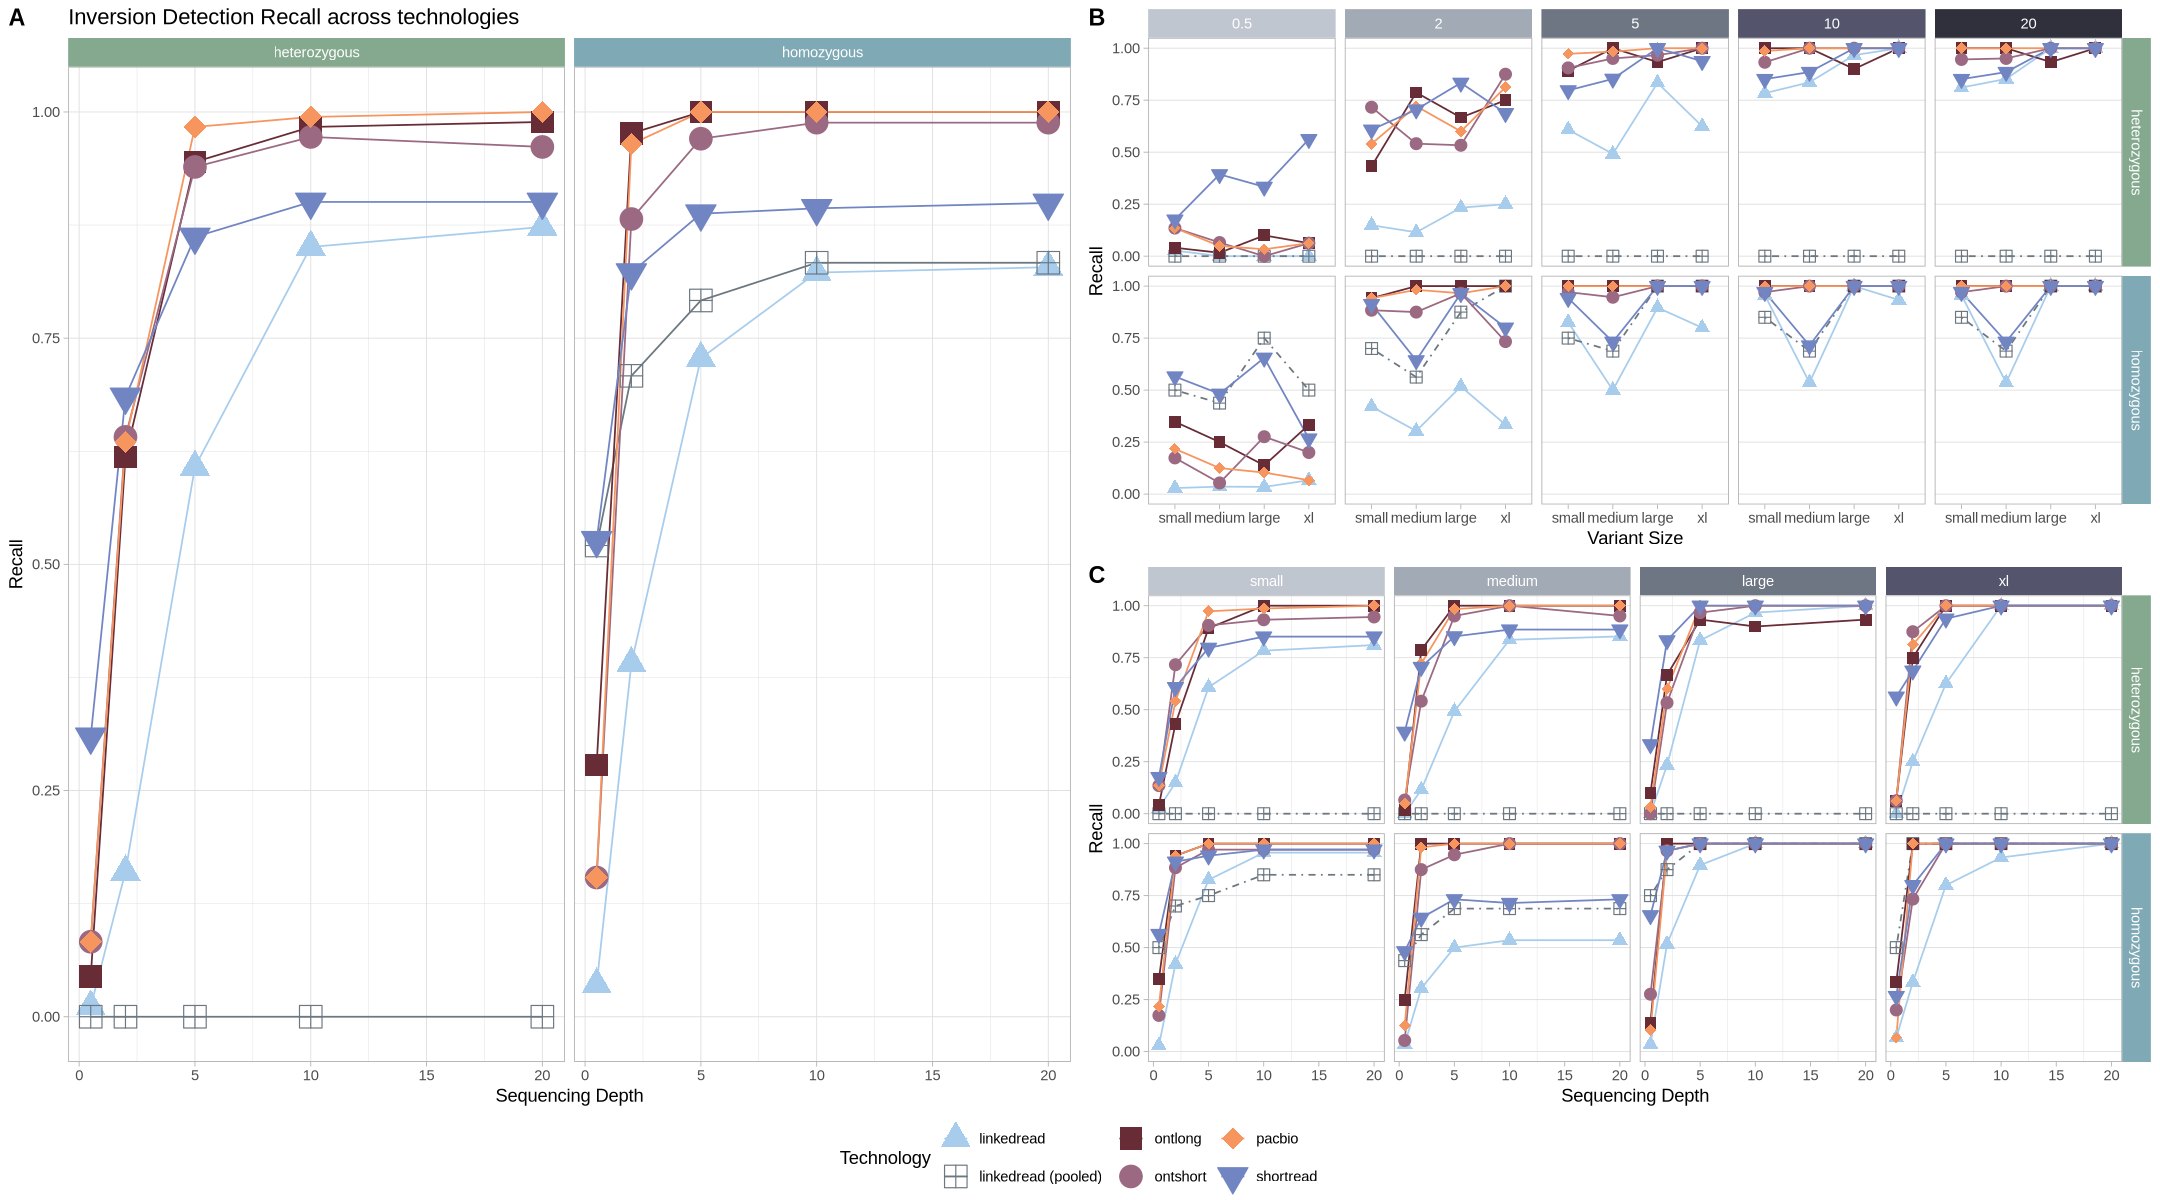

In [84]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("recall")

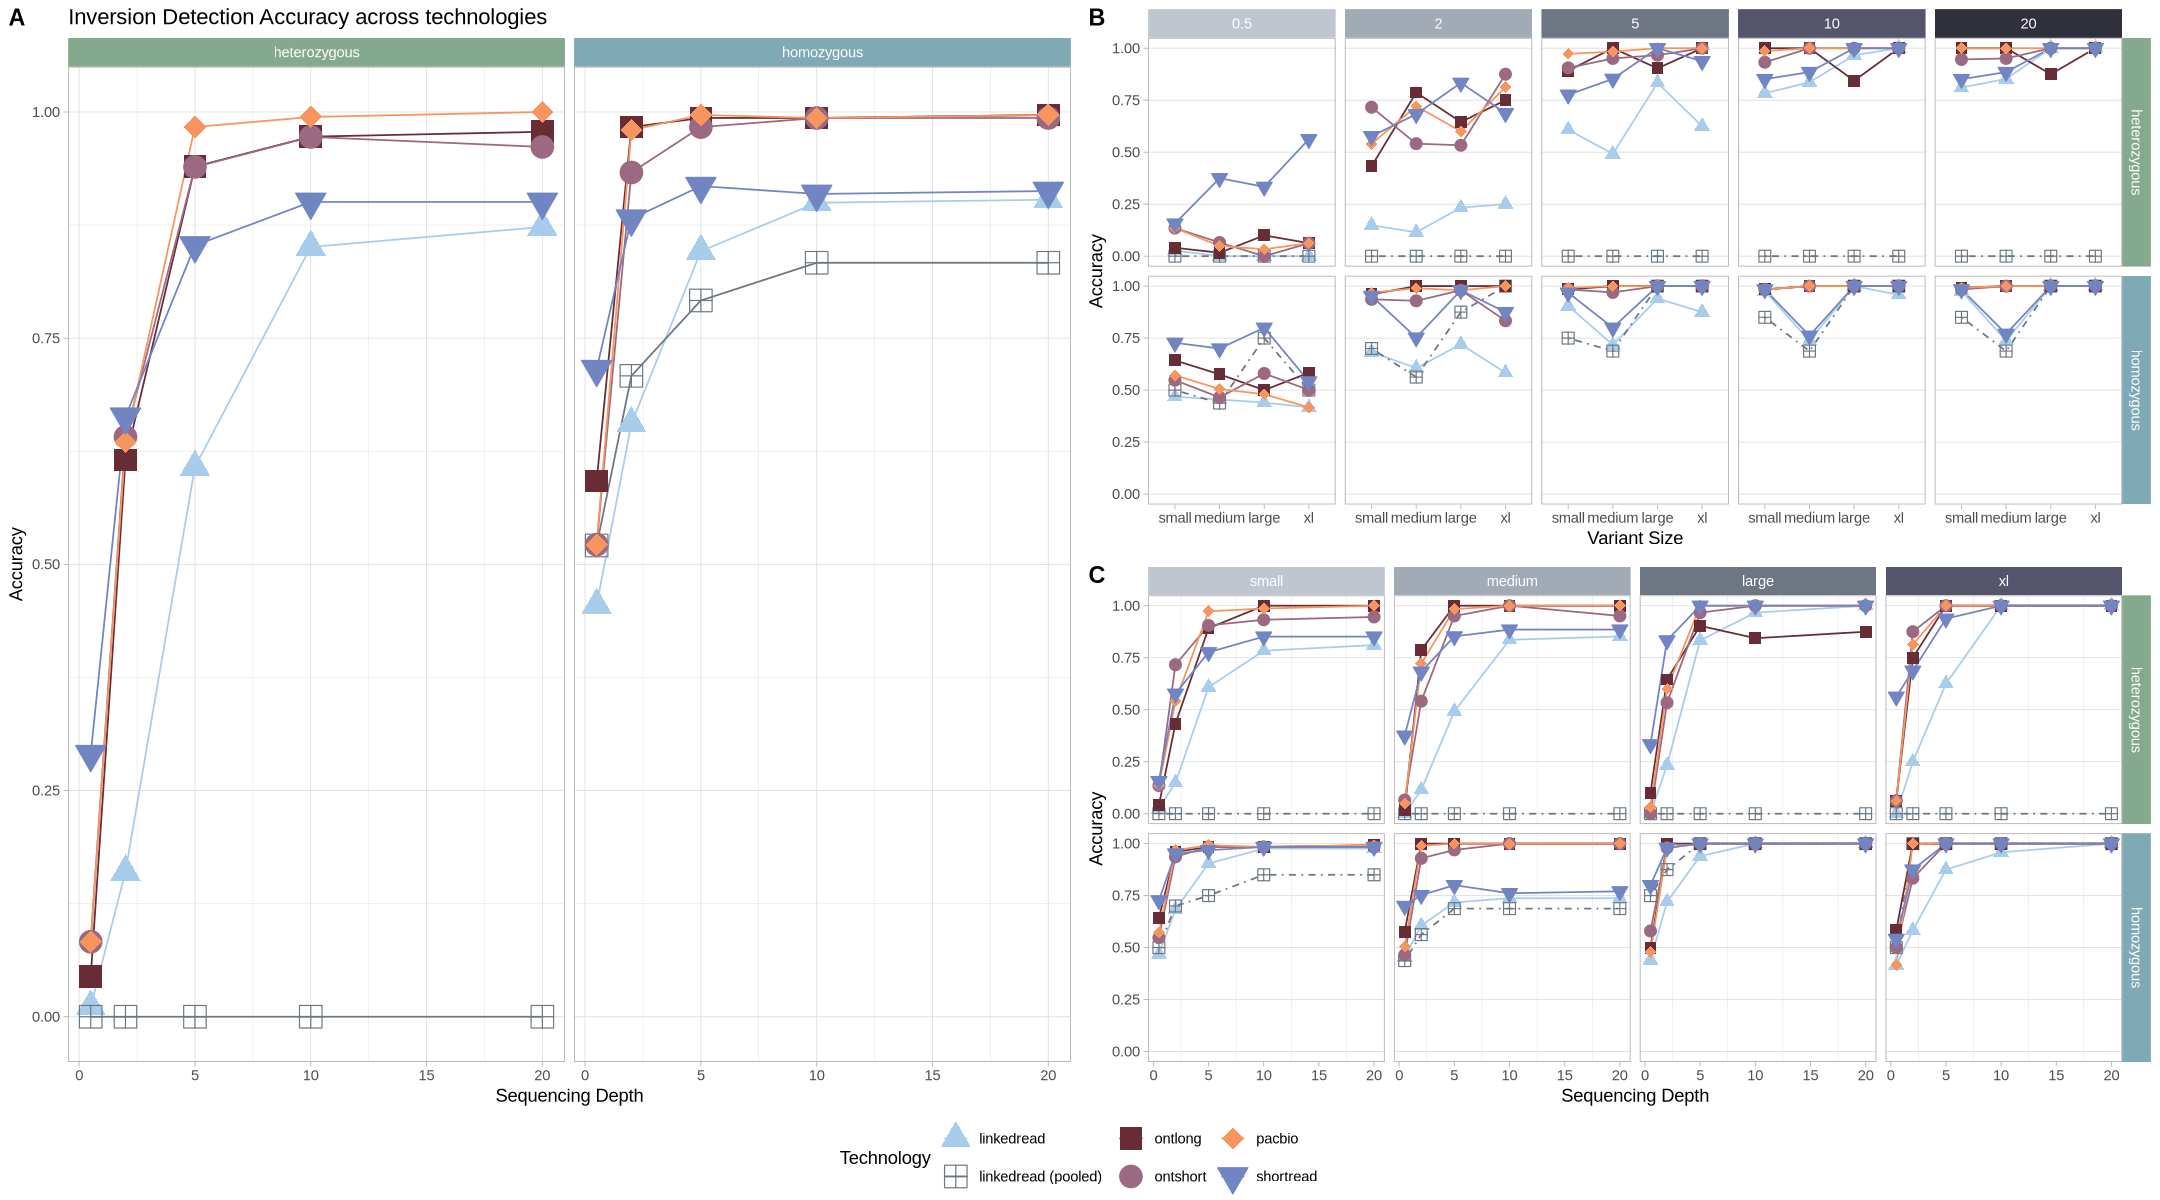

In [85]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("Accuracy")

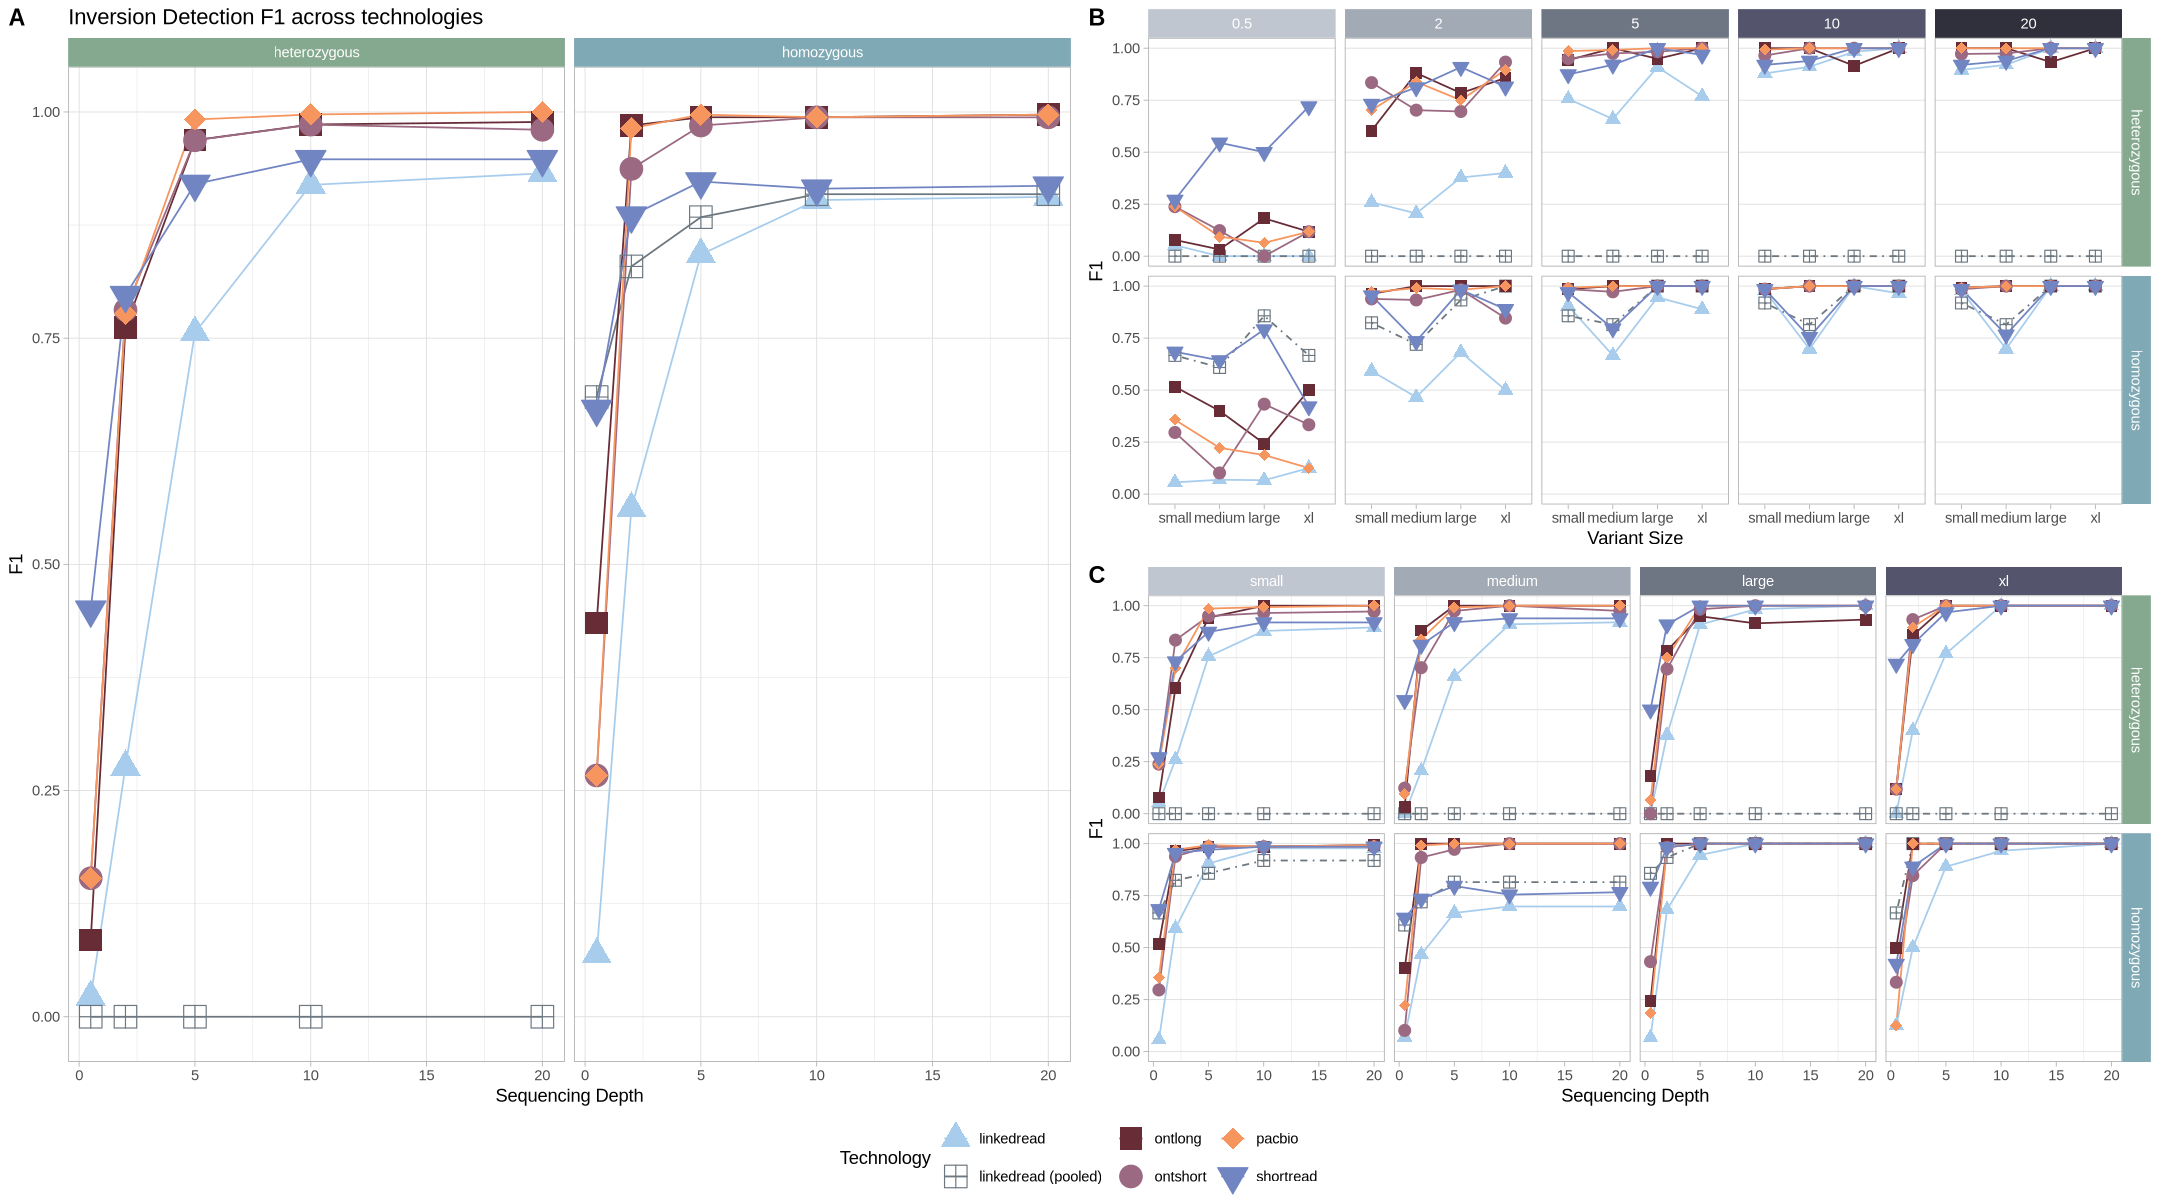

In [86]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("F1")

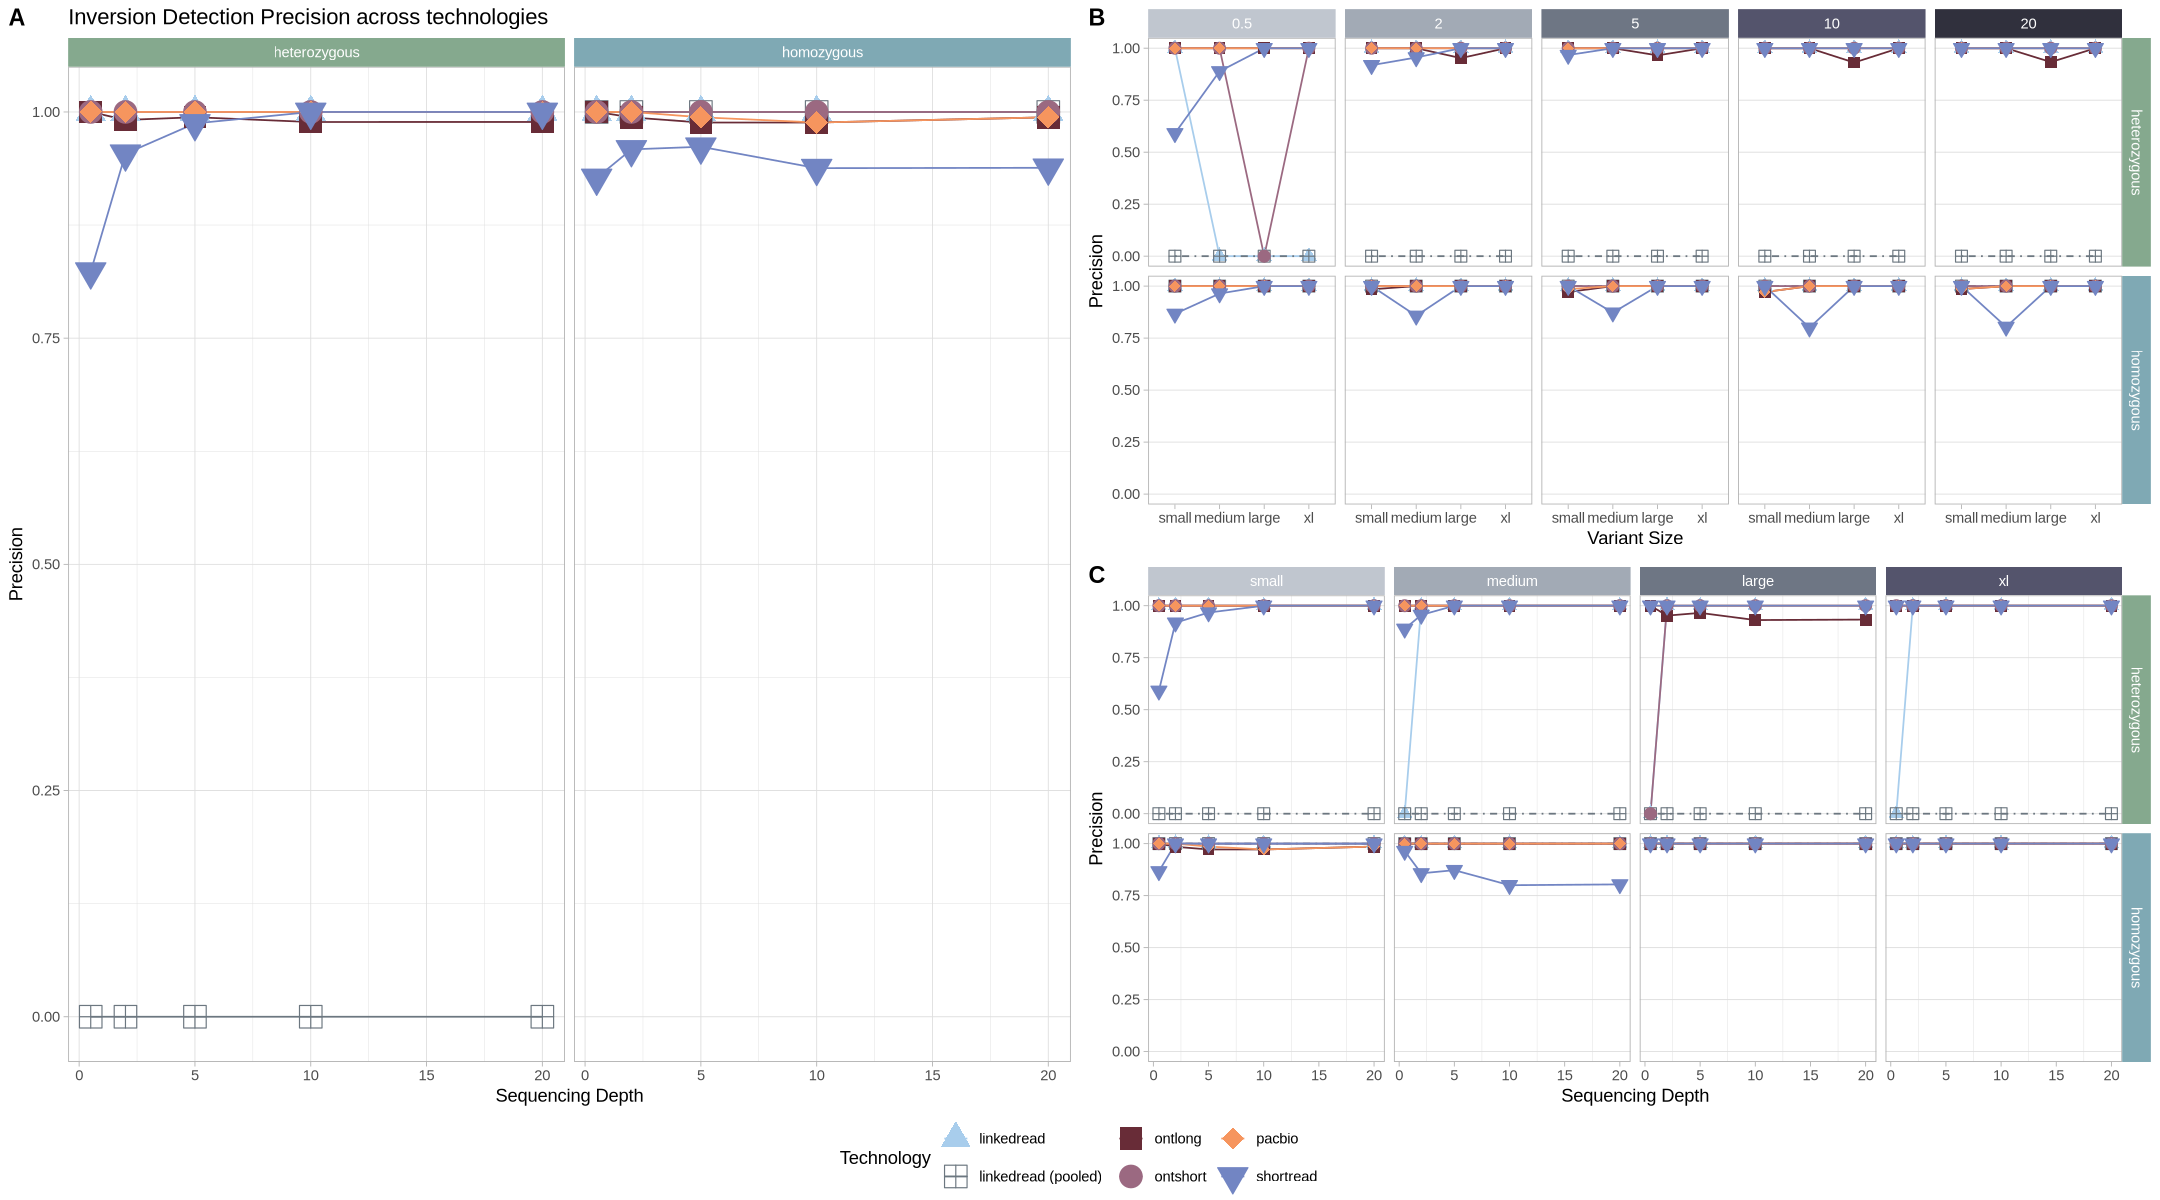

In [87]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("precision")

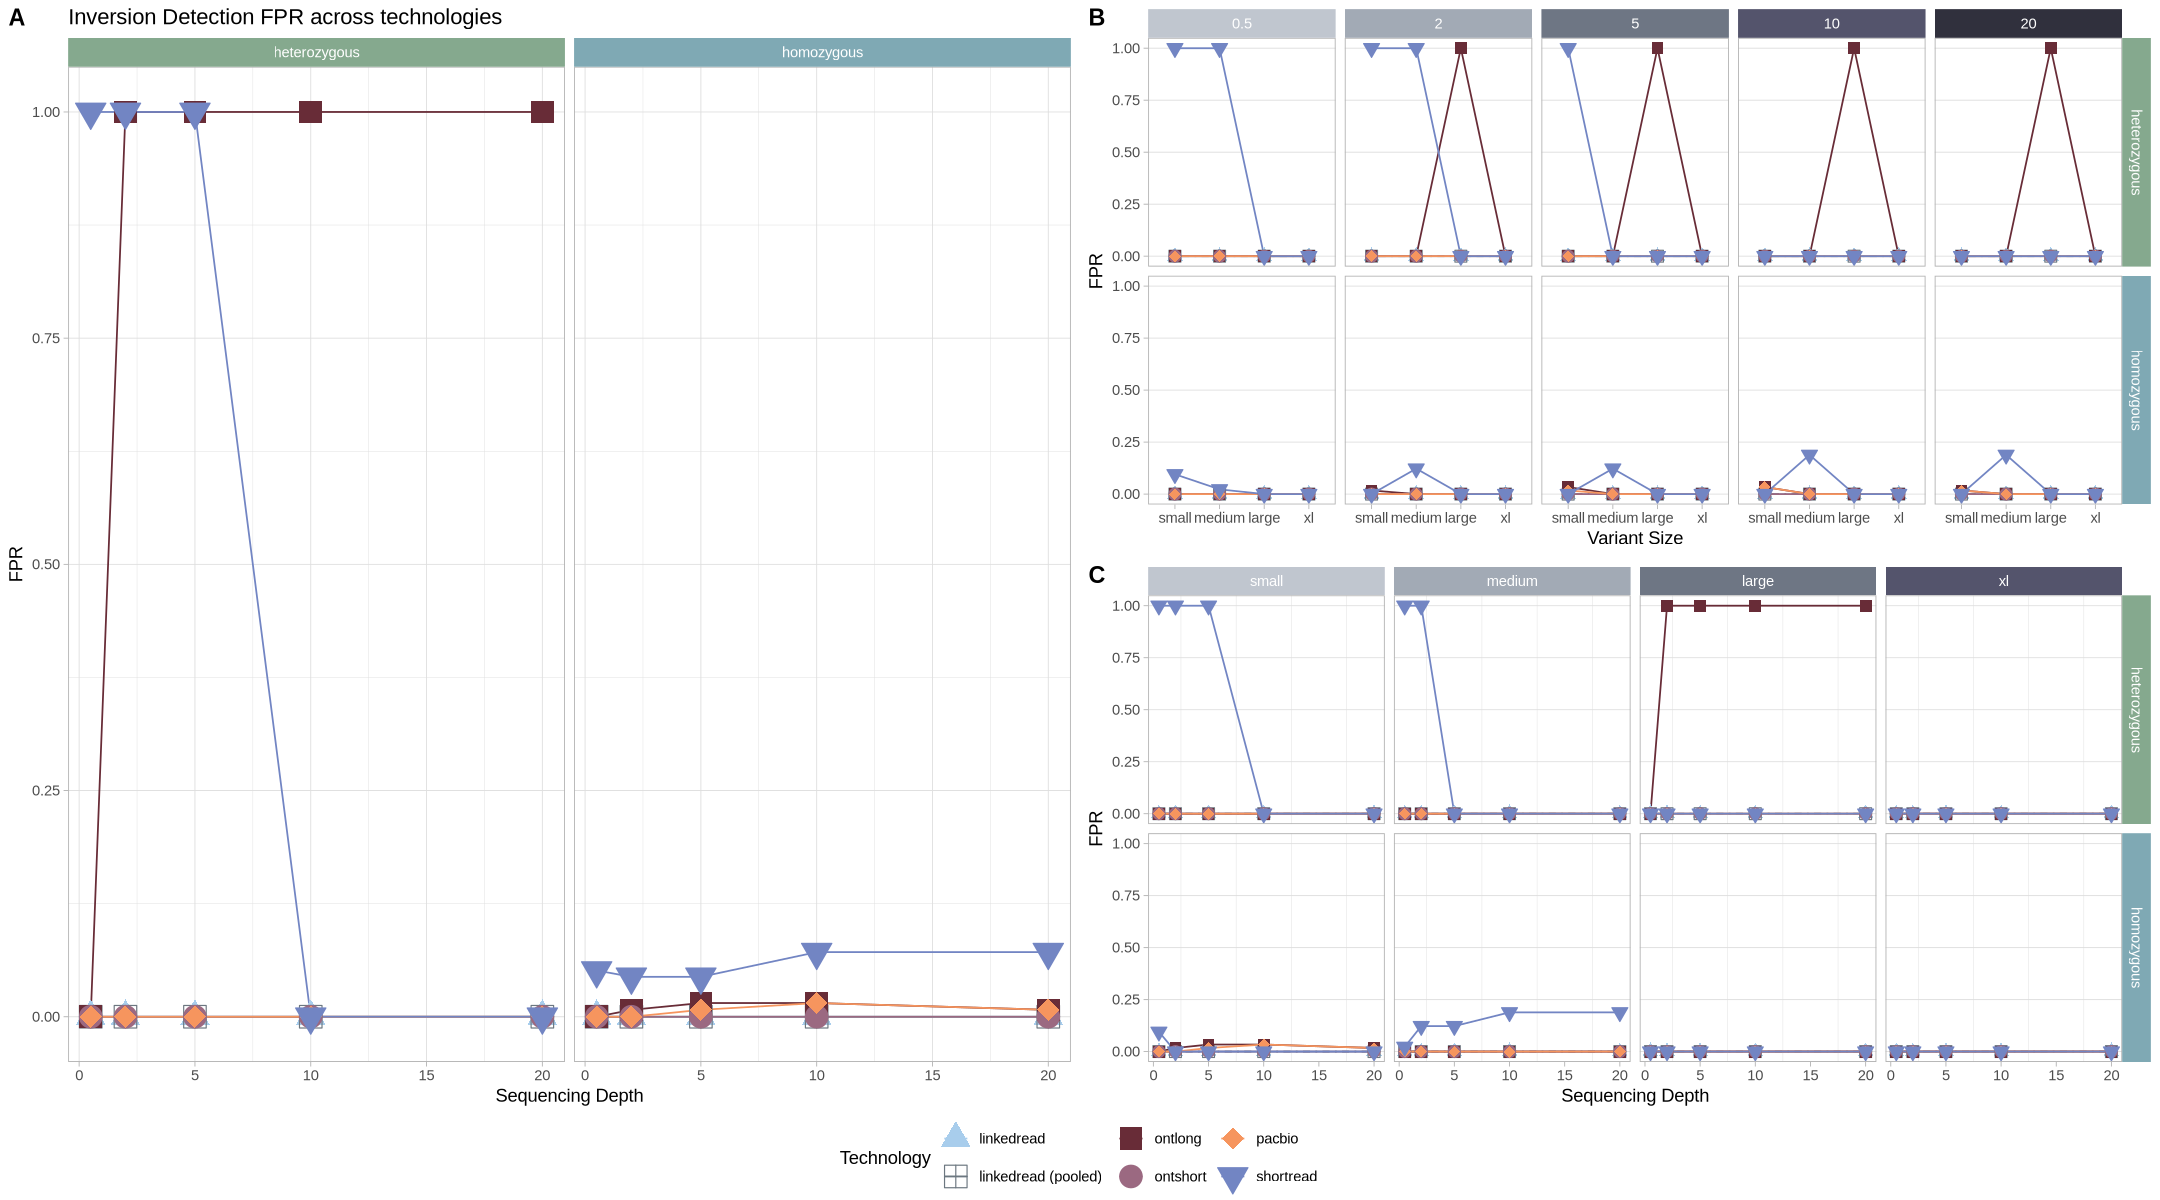

In [88]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("FPR")